In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

In [2]:
test = pd.read_csv('/kaggle/input/global-hack-week-detect-credit-card-fraud/test.csv')
test.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order
0,12367,2.067482,0.064300,1.472587,1.0,0.0,0.0,1.0
1,10942,9.078248,0.058169,1.494500,1.0,0.0,0.0,1.0
2,12171,2.156680,0.343030,0.419576,1.0,0.0,0.0,1.0
3,17800,3.087393,0.424519,0.879299,1.0,0.0,0.0,0.0
4,14230,14.162849,0.072577,1.262928,1.0,0.0,0.0,0.0


In [3]:
train = pd.read_csv('/kaggle/input/global-hack-week-detect-credit-card-fraud/train.csv')
train.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,16979,3.346870,0.620101,0.945172,1.0,0.0,0.0,1.0,0
1,12430,14.482868,0.170185,1.084836,1.0,0.0,0.0,1.0,0
2,19872,5.740898,0.167525,3.969652,1.0,0.0,0.0,1.0,0
3,18763,4.098570,0.291850,0.084129,1.0,1.0,0.0,1.0,1
4,13547,7.539580,0.294439,2.890880,1.0,1.0,0.0,0.0,0


In [4]:
combined = pd.concat([train,test])
combined.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,16979,3.346870,0.620101,0.945172,1.0,0.0,0.0,1.0,0.0
1,12430,14.482868,0.170185,1.084836,1.0,0.0,0.0,1.0,0.0
2,19872,5.740898,0.167525,3.969652,1.0,0.0,0.0,1.0,0.0
3,18763,4.098570,0.291850,0.084129,1.0,1.0,0.0,1.0,1.0
4,13547,7.539580,0.294439,2.890880,1.0,1.0,0.0,0.0,0.0


In [6]:
combined.infer_objects()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,16979,3.346870,0.620101,0.945172,1.0,0.0,0.0,1.0,0.0
1,12430,14.482868,0.170185,1.084836,1.0,0.0,0.0,1.0,0.0
2,19872,5.740898,0.167525,3.969652,1.0,0.0,0.0,1.0,0.0
3,18763,4.098570,0.291850,0.084129,1.0,1.0,0.0,1.0,1.0
4,13547,7.539580,0.294439,2.890880,1.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
1995,15863,7.936251,0.352425,0.226726,1.0,0.0,0.0,1.0,NaN
1996,7974,3.726659,7.242958,0.737863,1.0,0.0,0.0,0.0,NaN
1997,17024,18.853186,0.064697,2.425620,1.0,0.0,0.0,1.0,NaN
1998,16823,3.923652,0.948137,0.752398,1.0,1.0,0.0,1.0,NaN


In [9]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20000 non-null  int64  
 1   distance_from_home              20000 non-null  float64
 2   distance_from_last_transaction  20000 non-null  float64
 3   ratio_to_median_purchase_price  20000 non-null  float64
 4   repeat_retailer                 20000 non-null  float64
 5   used_chip                       20000 non-null  float64
 6   used_pin_number                 20000 non-null  float64
 7   online_order                    20000 non-null  float64
 8   fraud                           18000 non-null  float64
dtypes: float64(8), int64(1)
memory usage: 1.5 MB


In [10]:
combined.dtypes

id                                  int64
distance_from_home                float64
distance_from_last_transaction    float64
ratio_to_median_purchase_price    float64
repeat_retailer                   float64
used_chip                         float64
used_pin_number                   float64
online_order                      float64
fraud                             float64
dtype: object

In [12]:
combined.isnull().sum()/len('combined')*100

id                                    0.0
distance_from_home                    0.0
distance_from_last_transaction        0.0
ratio_to_median_purchase_price        0.0
repeat_retailer                       0.0
used_chip                             0.0
used_pin_number                       0.0
online_order                          0.0
fraud                             25000.0
dtype: float64

In [13]:
combined.describe().T

,count,mean,std,min,25%,50%,75%,max
id,20000.0,9999.500000,5773.647028,0.0,4999.750000,9999.500000,14999.250000,19999.000000
distance_from_home,20000.0,9.671857,9.663902,0.0,2.928337,6.253505,12.917474,62.099289
distance_from_last_transaction,20000.0,1.196399,2.658126,0.0,0.142928,0.427937,1.072616,51.653566
ratio_to_median_purchase_price,20000.0,1.101061,1.264182,0.0,0.336754,0.766183,1.420258,28.341698
repeat_retailer,20000.0,0.928550,0.257776,0.0,1.000000,1.000000,1.000000,2.000000
used_chip,20000.0,0.293050,0.457583,0.0,0.000000,0.000000,1.000000,7.000000
used_pin_number,20000.0,0.047300,0.219009,0.0,0.000000,0.000000,0.000000,8.000000
online_order,20000.0,0.700100,0.458225,0.0,0.000000,1.000000,1.000000,1.000000
fraud,18000.0,0.086000,0.280372,0.0,0.000000,0.000000,0.000000,1.000000


In [14]:
combined.shape

(20000, 9)

<Axes: >

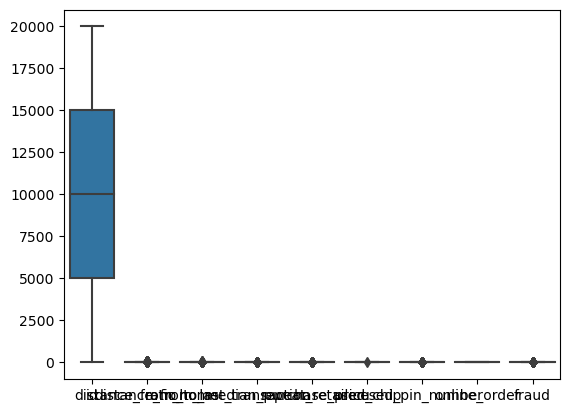

In [15]:
sns.boxplot(combined)

<Axes: >

/opt/conda/lib/python3.10/site-packages/IPython/core/events.py:89: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/opt/conda/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


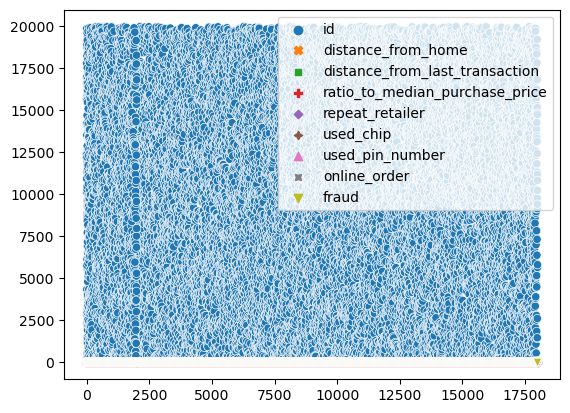

In [16]:
sns.scatterplot(combined)

<Axes: >

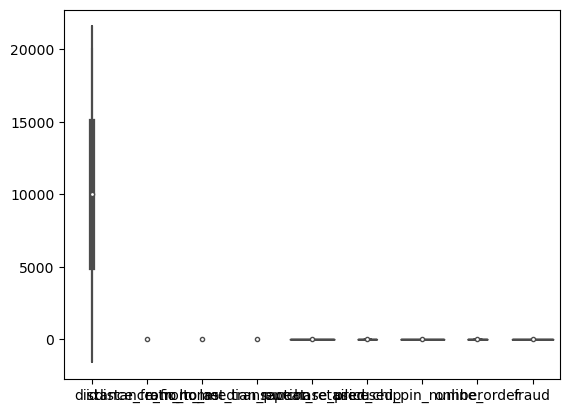

In [20]:
sns.violinplot(combined,color='red')

<Axes: ylabel='Density'>

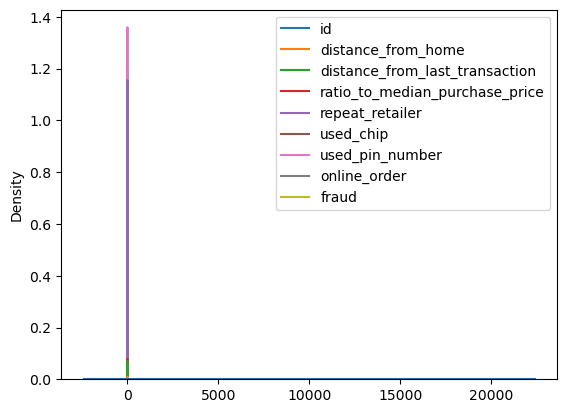

In [21]:
sns.kdeplot(combined)

<Axes: >

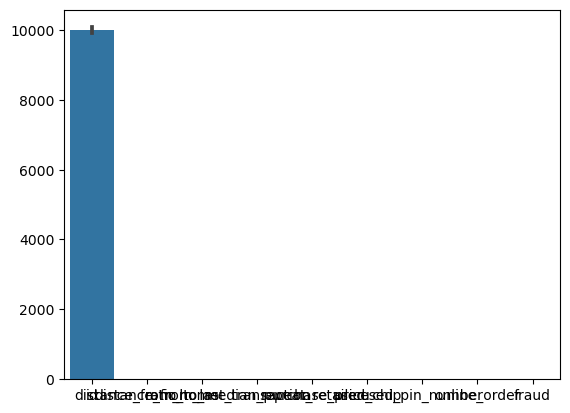

In [22]:
sns.barplot(combined)

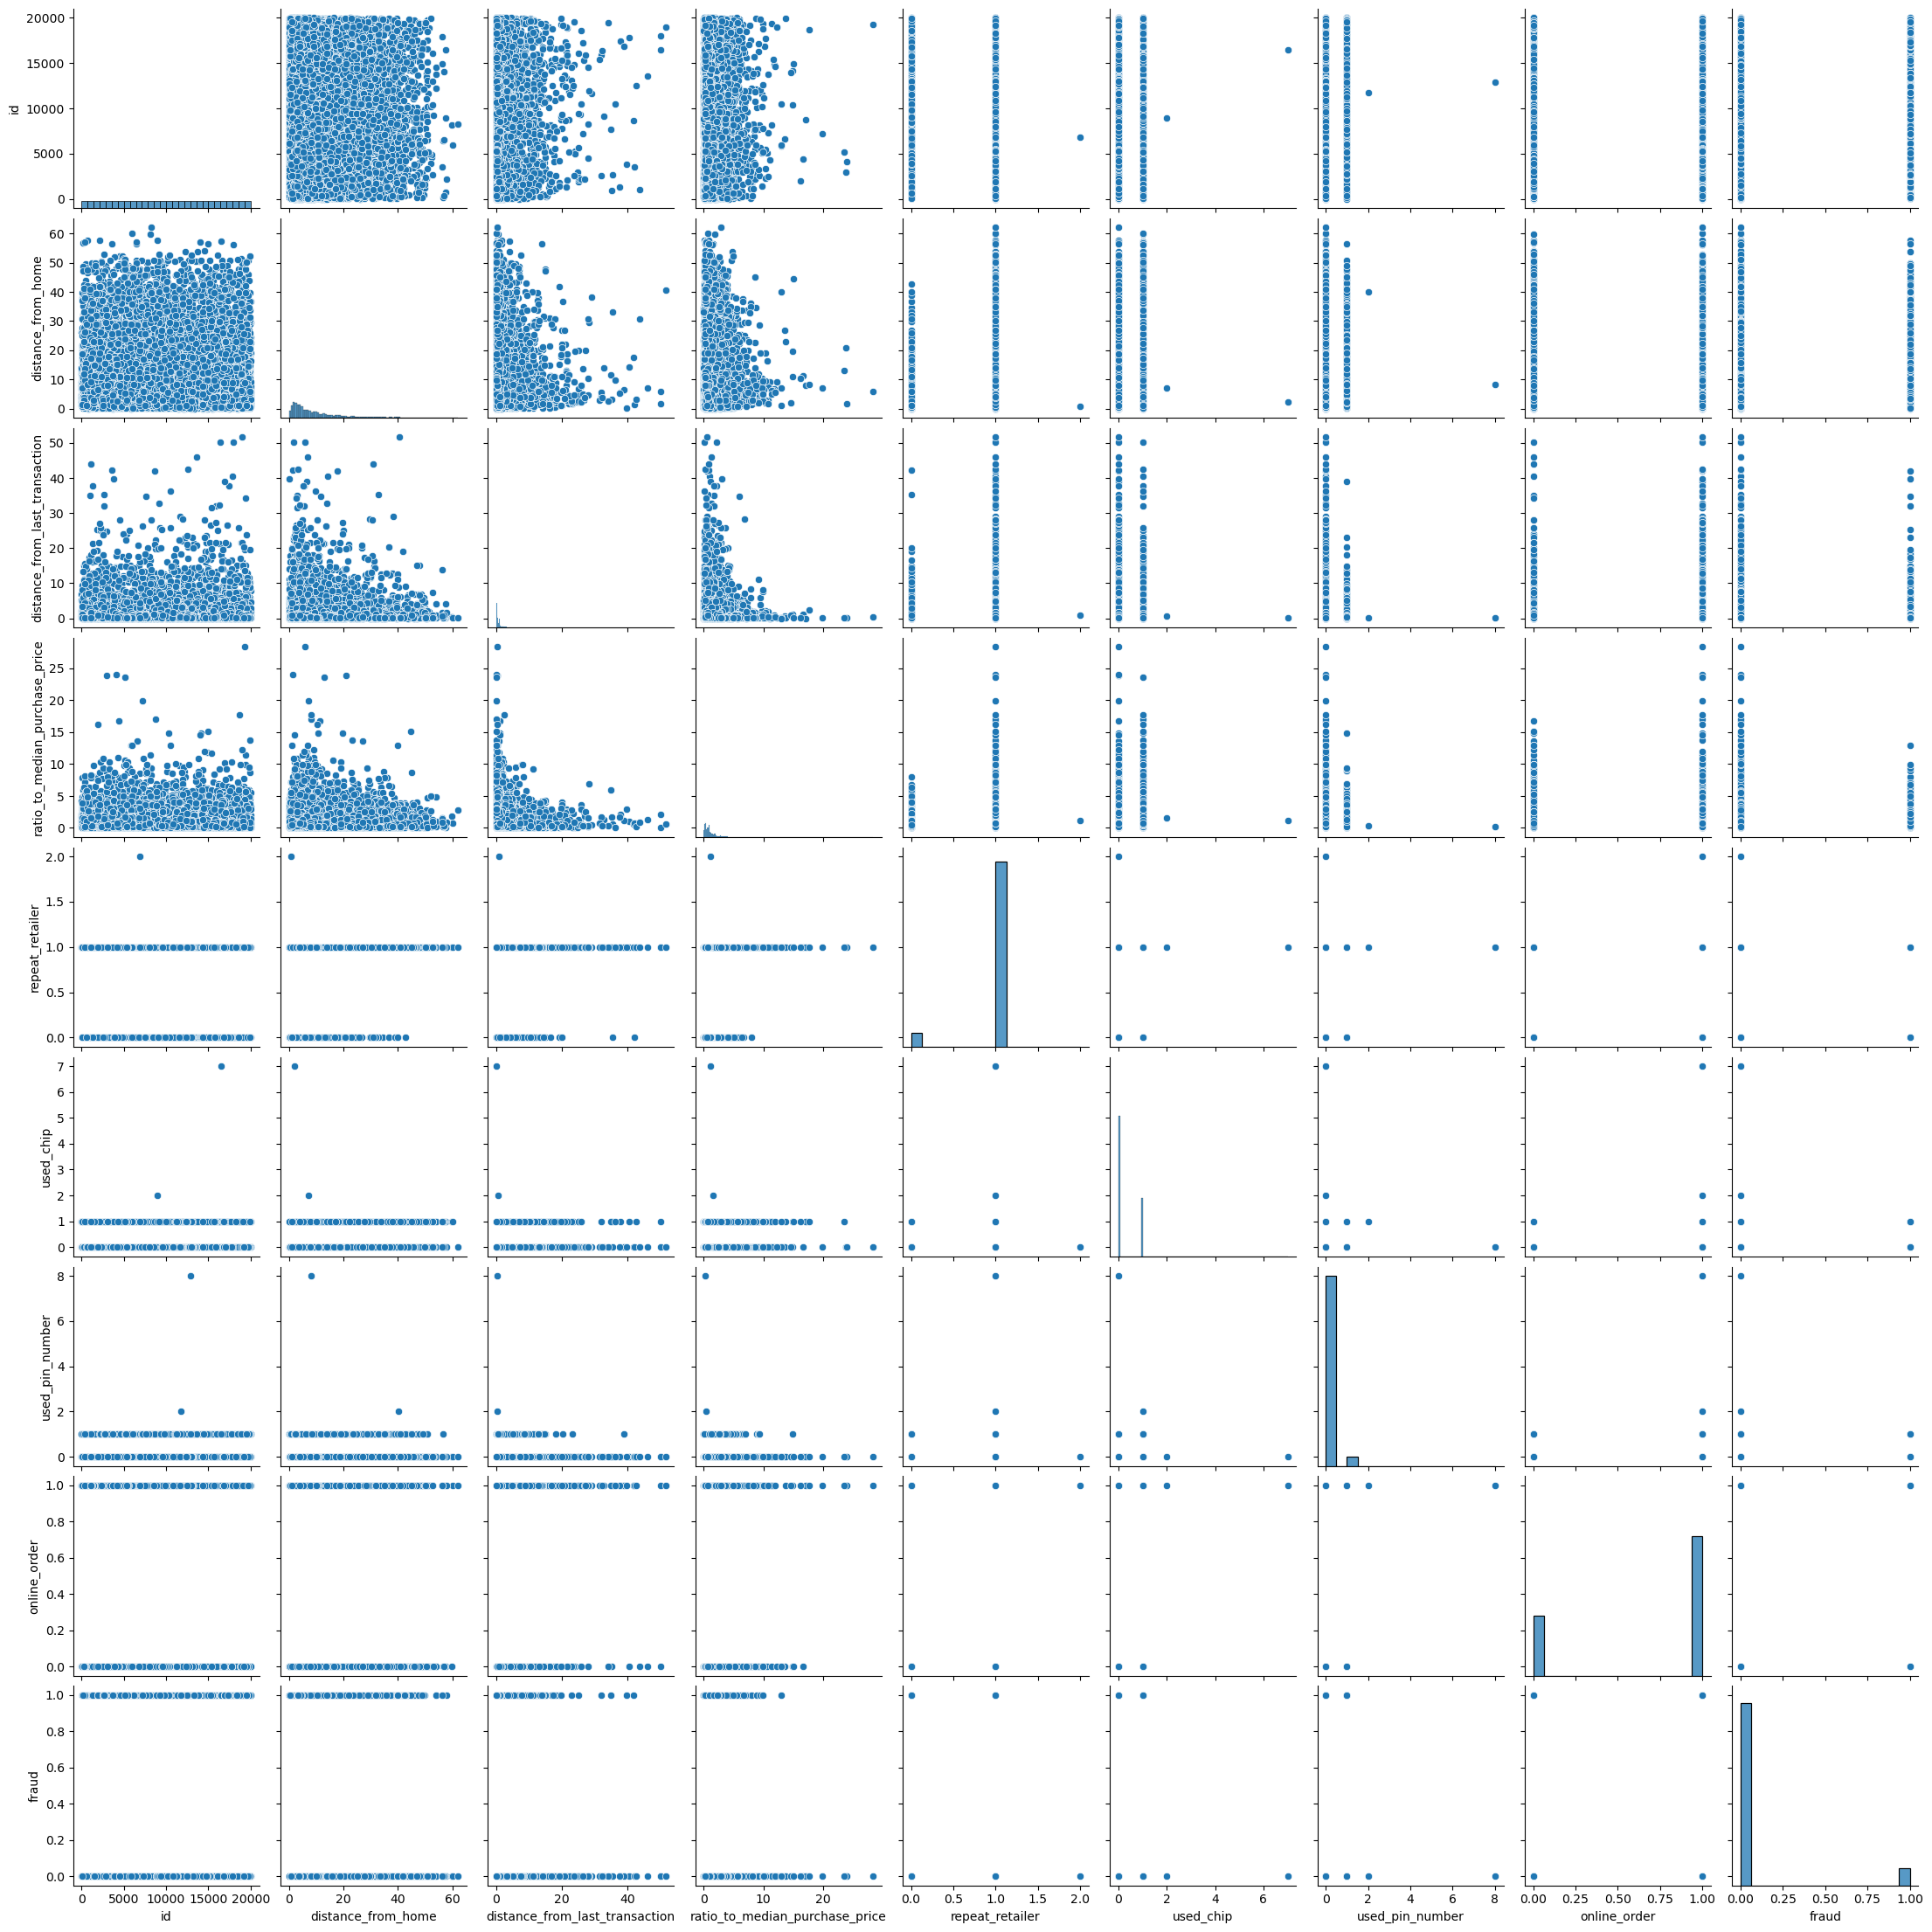

In [23]:
sns.pairplot(combined)

<Axes: >

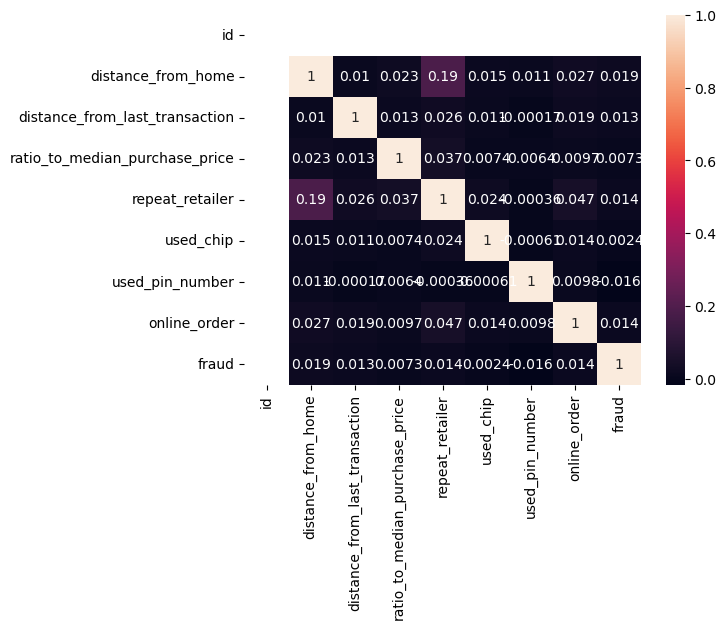

In [48]:
sns.heatmap(combined.corr(),annot=True,color='orange')

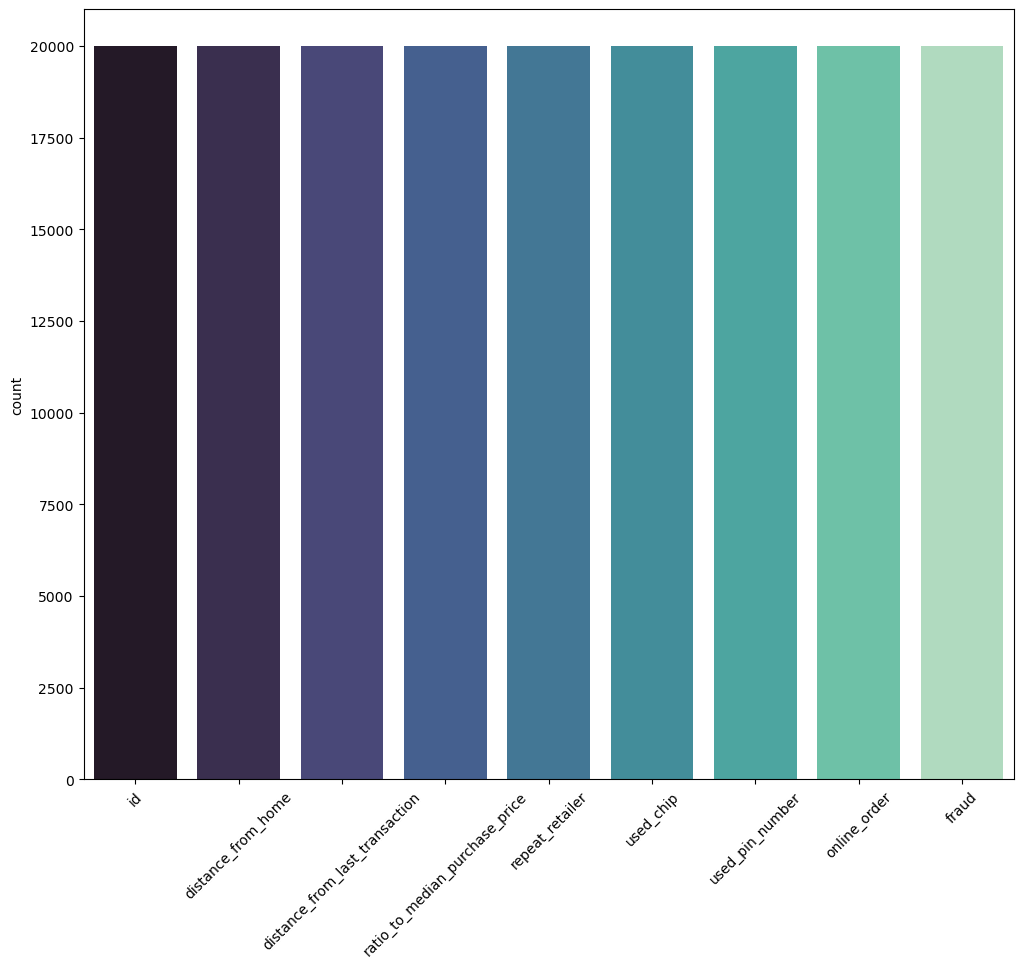

In [26]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako');
plt.xticks(rotation=45);

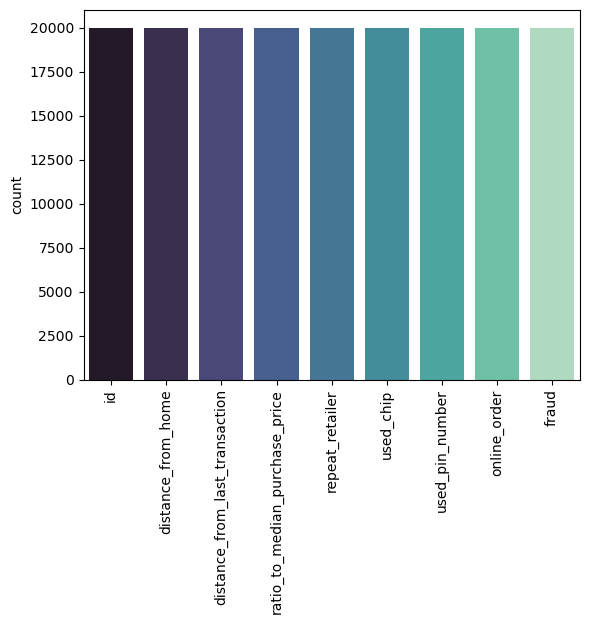

In [27]:
sns.countplot(combined,palette='mako');
plt.xticks(rotation=90);

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'id'),
  Text(1, 0, 'distance_from_home'),
  Text(2, 0, 'distance_from_last_transaction'),
  Text(3, 0, 'ratio_to_median_purchase_price'),
  Text(4, 0, 'repeat_retailer'),
  Text(5, 0, 'used_chip'),
  Text(6, 0, 'used_pin_number'),
  Text(7, 0, 'online_order'),
  Text(8, 0, 'fraud')])

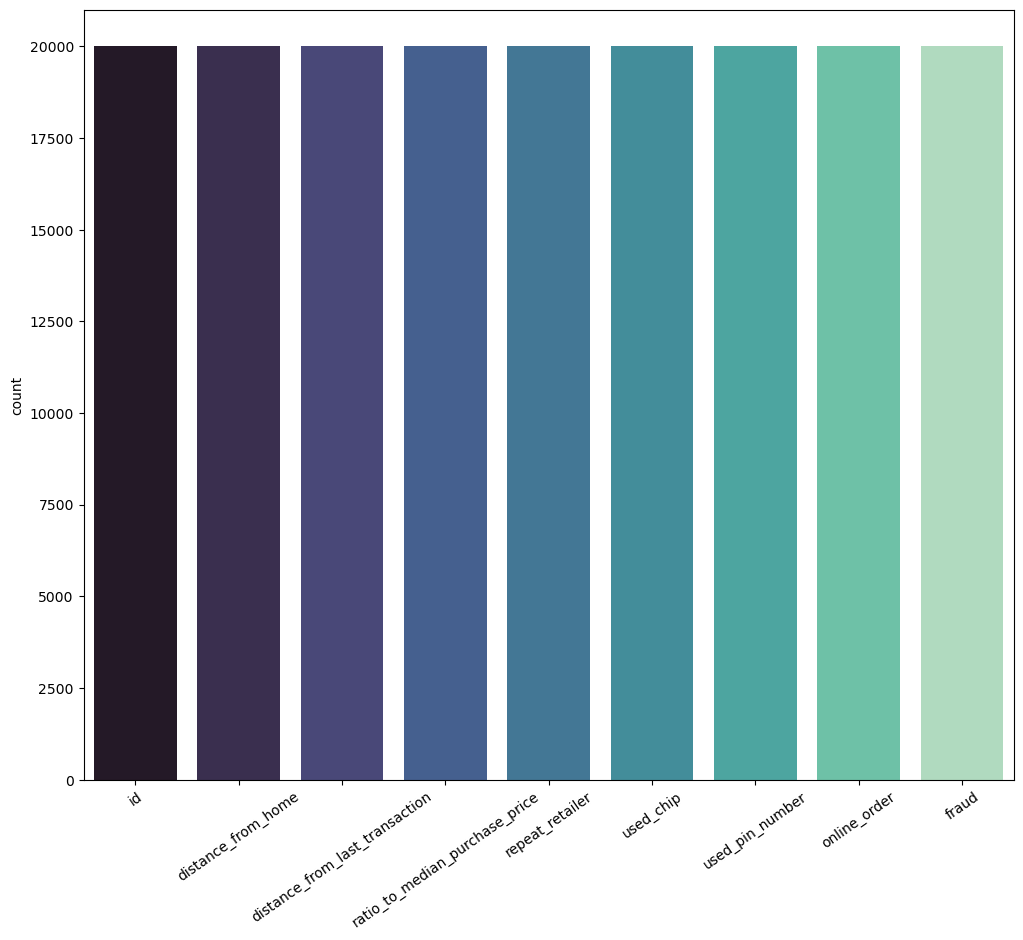

In [29]:
plt.figure(figsize=(12,10))
sns.countplot(combined,palette='mako')
plt.xticks(rotation=35)

In [5]:
cat_cols = combined.select_dtypes(include='object')


In [6]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

In [7]:
num_cols = combined.select_dtypes(include='number')

In [8]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

id
16979    1
4058     1
17466    1
10880    1
13876    1
        ..
9155     1
627      1
6134     1
1610     1
15626    1
Name: id, Length: 20000, dtype: int64
__________________________________________________
distance_from_home
0.000000    4
8.000000    2
1.000000    2
7.000000    2
3.000000    2
           ..
8.180112    1
3.256799    1
1.137049    1
5.489518    1
9.908939    1
Name: distance_from_home, Length: 19993, dtype: int64
__________________________________________________
distance_from_last_transaction
0.000000    31
1.000000     6
0.070000     2
1.004029     1
0.734294     1
            ..
0.048050     1
0.867607     1
0.153428     1
2.262726     1
0.063701     1
Name: distance_from_last_transaction, Length: 19964, dtype: int64
__________________________________________________
ratio_to_median_purchase_price
0.000000    11
1.000000     7
2.000000     3
0.900000     3
1.800000     2
            ..
0.333946     1
0.252365     1
3.164535     1
1.671815     1
2.923451     1


In [34]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

id                                9999.500000
distance_from_home                   9.989137
distance_from_last_transaction       0.929687
ratio_to_median_purchase_price       1.083504
repeat_retailer                      0.000000
used_chip                            1.000000
used_pin_number                      0.000000
online_order                         1.000000
fraud                                0.000000
dtype: float64


In [35]:
UL = Q3+(1.5*IQR)
LL  = Q1-(1.5*IQR)

In [39]:
combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]

In [40]:
combined_new.shape

(0, 9)

In [44]:
combined['id']=combined['id'].map({'Good':2,'Standard':1,'Poor':0})

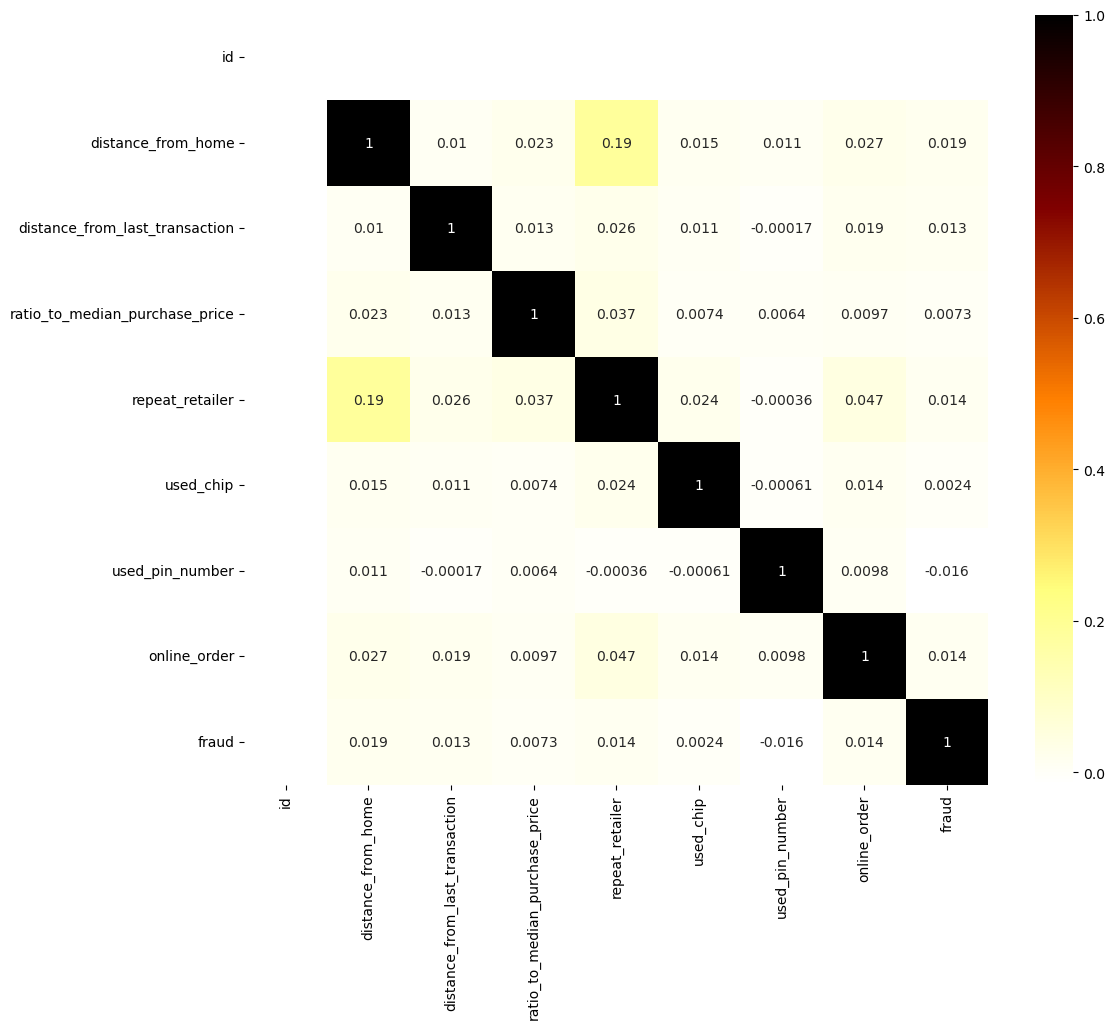

In [45]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show()

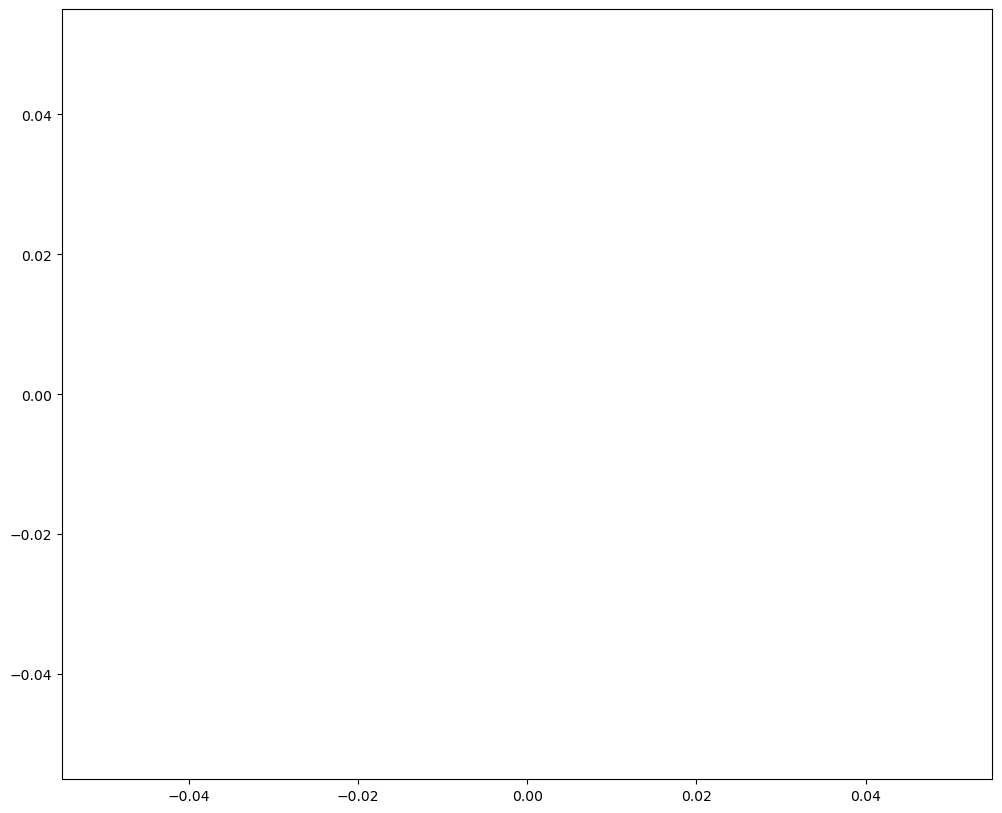

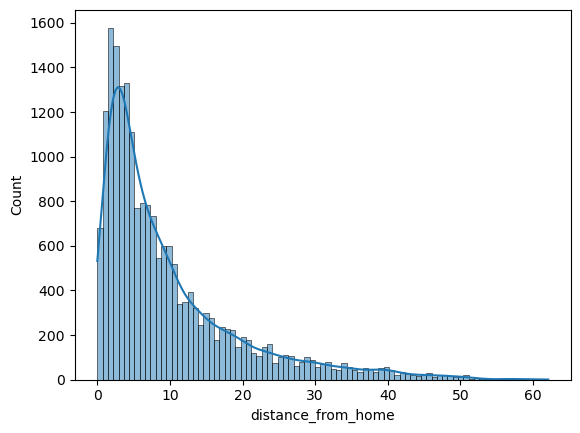

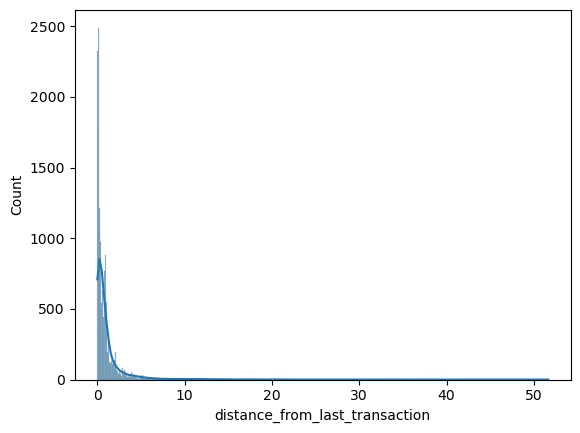

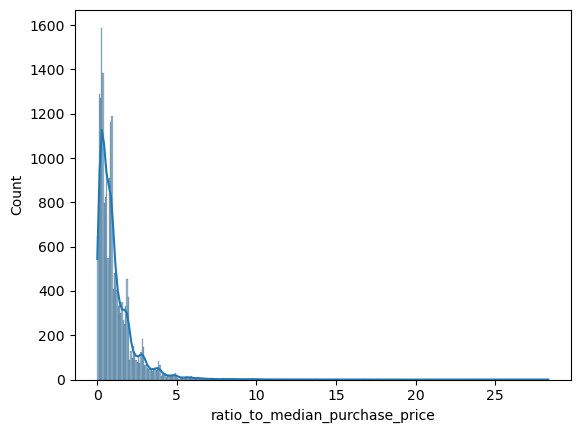

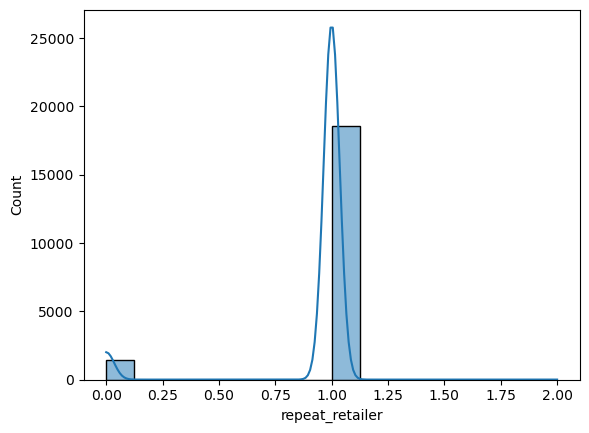

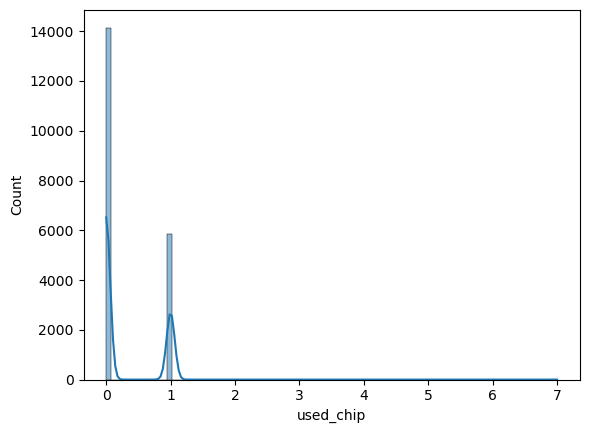

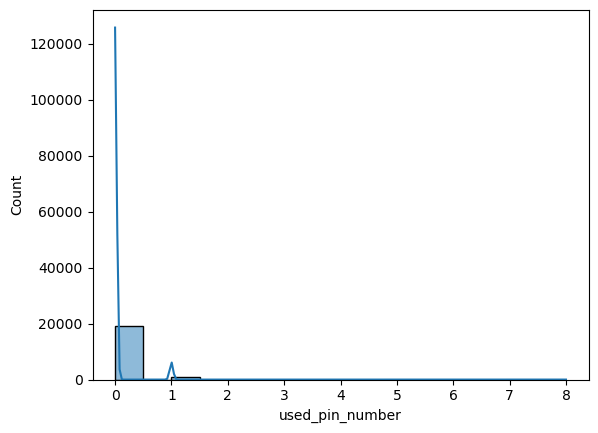

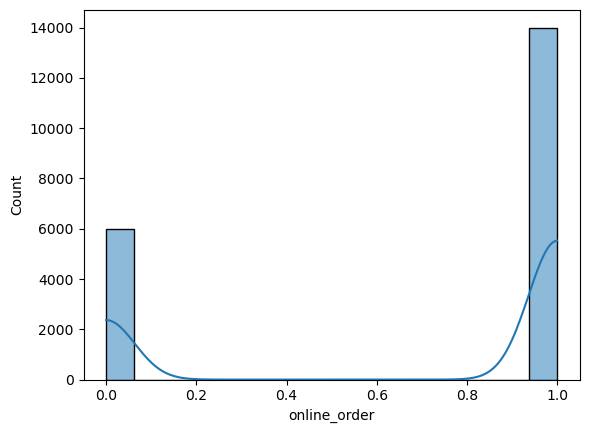

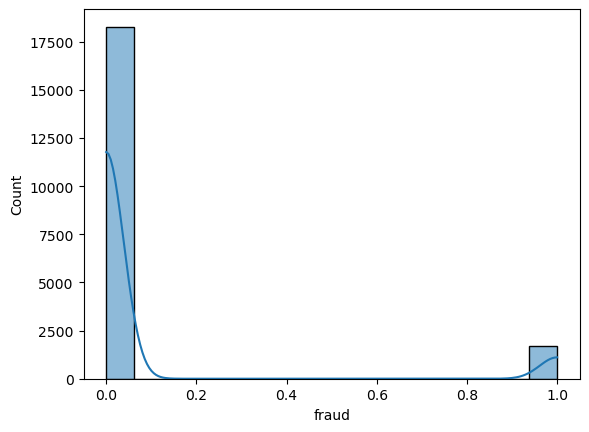

In [50]:
plt.figure(figsize=(12,10))
x=1
for i in num_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()

In [51]:
x=1
for i in cat_cols:
    sns.countplot(data=combined,x=i)
    print('\n')
    plt.show()

In [54]:
combined['id'].value_counts()

Series([], Name: id, dtype: int64)

In [55]:
combined['id'].unique()

array([nan])

In [56]:
combined['id'].isnull().sum()

20000

In [ ]:
# Replacing weird values

In [57]:
combined = combined.applymap(lambda x:x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)

In [58]:
combined.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,NaN,3.346870,0.620101,0.945172,1.0,0.0,0.0,1.0,0.0
1,NaN,14.482868,0.170185,1.084836,1.0,0.0,0.0,1.0,0.0
2,NaN,5.740898,0.167525,3.969652,1.0,0.0,0.0,1.0,0.0
3,NaN,4.098570,0.291850,0.084129,1.0,1.0,0.0,1.0,1.0
4,NaN,7.539580,0.294439,2.890880,1.0,1.0,0.0,0.0,0.0


In [59]:
# Treating type of distance_from_home
combined['distance_from_home'].value_counts().head(9).index[1:]

Float64Index([               8.0,                1.0,                7.0,
                             3.0, 11.746133070204856,  15.31852897242057,
                14.7164923353548,   7.75704047662912],
             dtype='float64')

In [63]:
# Rebuild type of distance_from_home
for i in combined['id'].value_counts().head(9).index[1:]:
    combined[i] = combined['id'].str.contains(i)

In [64]:
combined.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,NaN,3.346870,0.620101,0.945172,1.0,0.0,0.0,1.0,0.0
1,NaN,14.482868,0.170185,1.084836,1.0,0.0,0.0,1.0,0.0
2,NaN,5.740898,0.167525,3.969652,1.0,0.0,0.0,1.0,0.0
3,NaN,4.098570,0.291850,0.084129,1.0,1.0,0.0,1.0,1.0
4,NaN,7.539580,0.294439,2.890880,1.0,1.0,0.0,0.0,0.0


In [65]:
mapping = combined.groupby('id')['distance_from_home'].mean().to_dict()

In [66]:
combined['distance_from_home']=combined['id'].map(mapping)

In [67]:
combined['distance_from_home']=round(combined['distance_from_home'],0)

In [69]:
combined['distance_from_home']=combined['distance_from_home'].astype(str)

In [70]:
combined.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,NaN,nan,0.620101,0.945172,1.0,0.0,0.0,1.0,0.0
1,NaN,nan,0.170185,1.084836,1.0,0.0,0.0,1.0,0.0
2,NaN,nan,0.167525,3.969652,1.0,0.0,0.0,1.0,0.0
3,NaN,nan,0.291850,0.084129,1.0,1.0,0.0,1.0,1.0
4,NaN,nan,0.294439,2.890880,1.0,1.0,0.0,0.0,0.0


In [71]:
combined.isnull().sum()

id                                20000
distance_from_home                    0
distance_from_last_transaction        0
ratio_to_median_purchase_price        0
repeat_retailer                       0
used_chip                             0
used_pin_number                       0
online_order                          0
fraud                              2000
dtype: int64

In [72]:
combined['distance_from_home'].value_counts()

nan    20000
Name: distance_from_home, dtype: int64

In [73]:
# Replacing nm values in distance_from_home
combined['distance_from_home']=combined['distance_from_home'].replace({'NM':'Other'})

In [74]:
combined['distance_from_home'].value_counts()

nan    20000
Name: distance_from_home, dtype: int64

In [75]:
# Treating null value distance_from_last_transaction
mapping = combined.groupby('id').median()['distance_from_last_transaction'].to_dict()

/tmp/ipykernel_33/869369306.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.median is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mapping = combined.groupby('id').median()['distance_from_last_transaction'].to_dict()


In [76]:
combined['distance_from_last_transaction']=combined['id'].map(mapping)

In [77]:
combined['distance_from_last_transaction']=round(combined['distance_from_last_transaction'],0)

In [78]:
combined['distance_from_last_transaction'].value_counts()

Series([], Name: distance_from_last_transaction, dtype: int64)

In [81]:
combined['distance_from_last_transaction']=combined['distance_from_last_transaction'].replace({-1.0:1.0})

In [82]:
combined['distance_from_last_transaction'].value_counts()

Series([], Name: distance_from_last_transaction, dtype: int64)

In [85]:
combined['distance_from_last_transaction']=combined['distance_from_last_transaction'].astype(str)

In [86]:
combined.head()

,id,distance_from_home,distance_from_last_transaction,ratio_to_median_purchase_price,repeat_retailer,used_chip,used_pin_number,online_order,fraud
0,NaN,nan,nan,0.945172,1.0,0.0,0.0,1.0,0.0
1,NaN,nan,nan,1.084836,1.0,0.0,0.0,1.0,0.0
2,NaN,nan,nan,3.969652,1.0,0.0,0.0,1.0,0.0
3,NaN,nan,nan,0.084129,1.0,1.0,0.0,1.0,1.0
4,NaN,nan,nan,2.890880,1.0,1.0,0.0,0.0,0.0


In [87]:
cat_cols.shape,num_cols.shape

((20000, 0), (20000, 9))

In [88]:
combined.shape

(20000, 9)

In [89]:
combined.isnull().sum()

id                                20000
distance_from_home                    0
distance_from_last_transaction        0
ratio_to_median_purchase_price        0
repeat_retailer                       0
used_chip                             0
used_pin_number                       0
online_order                          0
fraud                              2000
dtype: int64

In [90]:
combined['ratio_to_median_purchase_price'].unique()

array([0.94517166, 1.08483641, 3.96965163, ..., 2.42562036, 0.75239811,
       2.92345129])

In [91]:
cat_cols

""
0
1
2
3
4
...
1995
1996
1997
1998


In [92]:
plt.figure(figsize=(12,10))
iterator=1
for i in cat_cols:
    plt.subplot(4,2,iterator)
    sns.countplot(combined[i],palette='mako')
    iterator+=1
    plt.xticks(rotation=90)
plt.tight_layout()

<Figure size 1200x1000 with 0 Axes>

In [ ]:
plt.figure(figsize=(12,16))
iterator=1
for i in num_cols:
    plt.subplot(10,3,iterator)
    sns.boxplot(combined[i])
    iterator+=1
plt.tight_layout()

In [ ]:
# Multivariate analysis for cat_cols

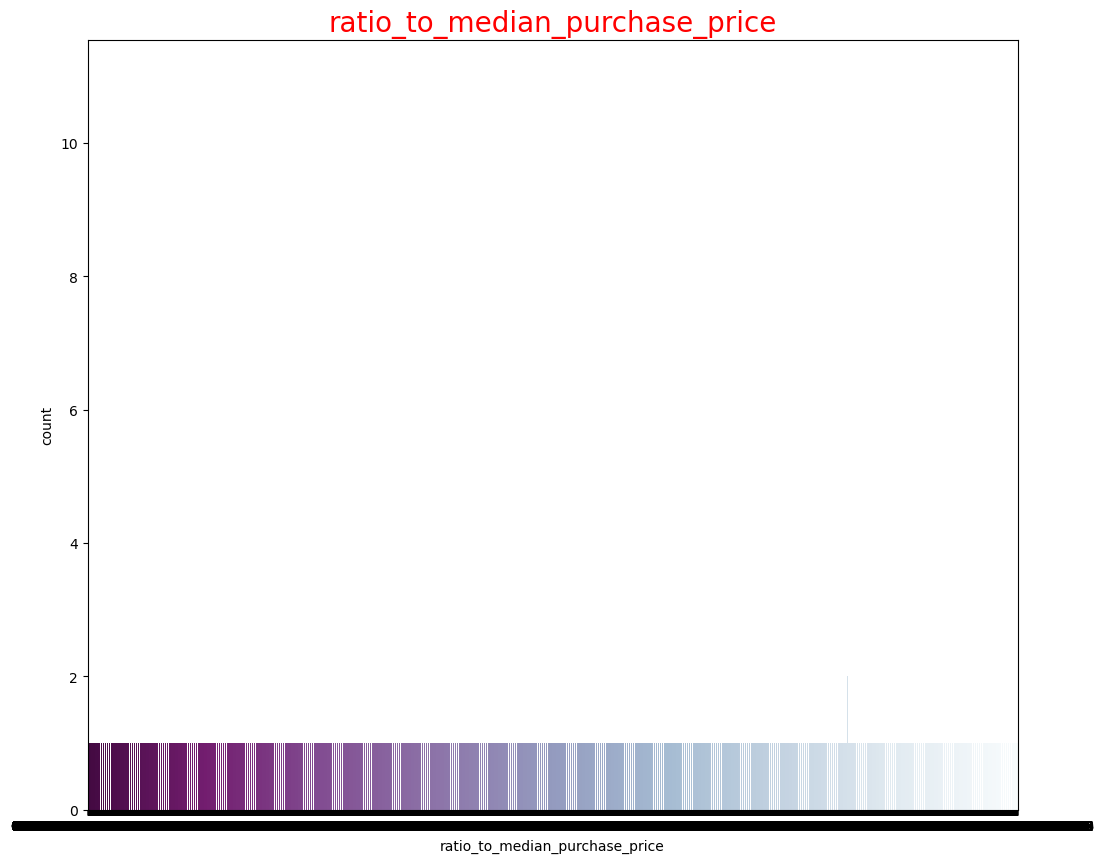

In [102]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,x='ratio_to_median_purchase_price',palette='BuPu_r')
plt.title('ratio_to_median_purchase_price',size=20,color='Red')
plt.show()

In [96]:
combined['ratio_to_median_purchase_price'].value_counts(normalize=True)*100

0.000000    0.055
1.000000    0.035
2.000000    0.015
0.900000    0.015
1.800000    0.010
            ...  
0.333946    0.005
0.252365    0.005
3.164535    0.005
1.671815    0.005
2.923451    0.005
Name: ratio_to_median_purchase_price, Length: 19979, dtype: float64

In [21]:
train.shape[0]

18000

In [22]:
new_train=combined.iloc[0:train.shape[0],:]

In [23]:
new_test=combined.iloc[train.shape[0]:,:]

In [24]:
train.shape,new_train.shape,test.shape,new_test.shape

((18000, 9), (18000, 9), (2000, 8), (2000, 9))

In [25]:
import scipy.stats as stats


In [26]:
cat_cols = combined.select_dtypes(include='object')
num_cols = combined.select_dtypes(include='number')

In [27]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['id']==0,i]
    one=new_train.loc[new_train['id']==1,i]
    two=new_train.loc[new_train['id']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

/opt/conda/lib/python3.10/site-packages/scipy/stats/_stats_py.py:3869: DegenerateDataWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  warnings.warn(stats.DegenerateDataWarning(msg))


In [29]:
sig_cat=[]
for i in cat_cols:
    a=pd.crosstab(new_train[i],new_train['id'])
    tsat,pval,dof,freq=stats.chi2_contingency(a)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [30]:
train_new=new_train.loc[:,sig_cat+sig_num]

In [31]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [ ]:
# Checking for multicollinearity

In [32]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [34]:
train_new

""
0
1
2
3
4
...
17995
17996
17997
17998


In [ ]:
# Scaling the col

In [42]:
scaling =[]

In [43]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [44]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [45]:
test_new

""
0
1
2
3
4
...
1995
1996
1997
1998
